# Cross-Company FEC Analysis

A modern port of the original SAS pipeline (see [the design doc](../docs-src/sas-port.md) for context).

The SAS code (~1,100 lines of `DATA` steps and `PROC TABULATE`) takes
Schedule-A receipts for Fortune-500 employees, joins committee→party
lookups, infers gender by first name, and applies the **60 % rule** to
assign each contributor to a party. This notebook re-expresses the same
11-step pipeline as ~10 DuckDB CTEs and pandas calls — and pushes
further with multi-company comparisons, time series, and the embedded
`committee.party` field that OpenFEC's API now provides directly.

## What this notebook produces

1. **`stats5all`** — final contributor-level table (one row per person, 60 %-rule classified).
2. **`saspac3all`** — final contribution-level table (one row per transaction).
3. **`company_contributors`** — SAS-parity summary (one row per employer, contributor counts + dollars by D/R/Other × M/F/U).
4. **`company_contributions`** — SAS-parity summary (one row per employer, transaction counts + dollars).
5. Cross-company stacked bars, monthly time series, state distribution, top recipient committees.
6. **Schedule B recipient-side view** (`/schedules/schedule_b/`) — outflow from each company's top recipient PAC.
7. **Committee fill-in** (`/committee/{id}/`) — authoritative party / type for committees the embedded Schedule A field left null.
8. **Candidate enrichment** (`/candidate/{id}/`) — authoritative party / office for the actual humans those PACs back. Lets us slice *outflow by recipient party*.

Every section maps back to specific lines in `sascsvc19.sas` so a SAS
reader can cross-reference. Sections 1–11 + 15 are the SAS port; sections 12–14
exercise FEC API endpoints the SAS code never had access to.

*Notes on form: DuckDB queries run via the `run_sql()` helper, which prints the SQL syntax-highlighted before executing it — so you read it the same way the engine does. The state chart is rendered twice (matplotlib + plotly) as a quick demo that this notebook isn't locked to one chart library.*


## 1. Configuration

Five Fortune-500 employers with varied political profiles, the same
2019–2020 cycle the SAS analysis covered. The notebook auto-skips any
company whose JSON isn't in `output/schedule_a/` — fetch what you have,
the rest just don't appear.


In [1]:
# Employers to include — order = display order in charts/tables.
COMPANIES = [
    'TRACTOR SUPPLY',
    'MICROSOFT',
    'EXXON MOBIL',
    'WALMART',
    'LOCKHEED MARTIN',
]

MIN_DATE = '2019-01-01'
MAX_DATE = '2020-12-31'
PARTY_THRESHOLD = 0.60   # SAS 60 % rule, sascsvc19.sas:534+
GENDER_HIGH_CONF = {'male', 'female'}   # equivalent to SAS probability >= 0.9 cutoff
PAGES_PER_COMPANY = 2    # 200 records each — keeps cold-fetch under a minute


In [2]:
import json
import os
import re
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

%matplotlib inline

# Resolve paths from project root whether launched from notebooks/ or root.
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

from fec_client import FECClient   # disk-cached OpenFEC client

ROOT = Path.cwd()
CSV_DIR = ROOT / 'csv'
SCHEDULE_A_DIR = ROOT / 'output' / 'schedule_a'
TABLES_DIR = ROOT / 'output' / 'tables'
CHARTS_DIR = ROOT / 'output' / 'charts'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Print paths relative to the project root so notebook outputs stay portable.
def _rel(p: Path) -> str:
    try:    return str(p.relative_to(ROOT))
    except ValueError: return str(p)

# Show DuckDB SQL with syntax highlighting then execute it. Single source of truth:
# anyone scanning the notebook reads the SQL the same way DuckDB does.
def run_sql(con, sql: str, *, show: bool = True) -> 'pd.DataFrame':
    if show:
        display(Markdown(f'```sql\n{sql.strip()}\n```'))
    return con.execute(sql).df()

print(f'project root : .')
print(f'schedule_a   : {_rel(SCHEDULE_A_DIR)}')
print(f'tables out   : {_rel(TABLES_DIR)}')


project root : .
schedule_a   : output/schedule_a
tables out   : output/tables


## 2. Lookups

The SAS pipeline takes four lookup tables (`AllPacs`, `Aristotle`,
`name_gender`, `CompanyRank`) plus the `$COMPANYF.`/`$AGENCYF.`
PROC FORMAT mappings. We replicate them inline.

- **`AllPacs.xslx.csv`** — ~35K rows committee_id → party affiliation (real SAS lookup, bundled in `csv/`)
- **`Aristotle1.xlsx.csv`** — 25 party codes → full party name (real SAS lookup, bundled in `csv/`)
- **Gender** — `gender-guesser` library replaces `name_gender.csv` (≈ 50K names, MIT-licensed)
- **State name** — inline US Postal abbrev → full name dict (replaces `stnamel()`)
- **Display company name** — inline dict (replaces `$COMPANYF.` formats)


In [3]:
allpacs   = pd.read_csv(CSV_DIR / 'AllPacs.xslx.csv')
aristotle = pd.read_csv(CSV_DIR / 'Aristotle1.xlsx.csv')

# Display names for our 5 employers (replaces SAS $COMPANYF. PROC FORMAT).
COMPANY_DISPLAY = {
    'TRACTOR SUPPLY':  'Tractor Supply',
    'MICROSOFT':       'Microsoft',
    'EXXON MOBIL':     'Exxon Mobil',
    'WALMART':         'Walmart',
    'LOCKHEED MARTIN': 'Lockheed Martin',
}

# Replaces SAS stnamel(state) — 50 states + DC + 5 territories.
STATE_NAMES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia',
    'PR': 'Puerto Rico', 'VI': 'Virgin Islands', 'GU': 'Guam', 'AS': 'American Samoa',
    'MP': 'Northern Mariana Islands',
}

print(f'AllPacs   : {len(allpacs):>6,} rows  → covers {allpacs["Political Affiliation"].nunique()} party codes')
print(f'Aristotle : {len(aristotle):>6,} rows  → {len(aristotle)} party codes')
print(f'States    : {len(STATE_NAMES):>6,} entries')
display(aristotle)


AllPacs   : 35,689 rows  → covers 146 party codes
Aristotle :     25 rows  → 25 party codes
States    :     56 entries


,Code,Party
0,A,American Independent
1,B,Constitution Party
2,C,Consumer
3,D,Democrat
4,F,Reform
5,G,Green
6,H,Liberal
7,I,Independent
8,J,UMOJA
9,K,Independent NM Party


## 3. Fetch — Schedule A (individual contributions)

Each fetch is disk-cached; subsequent re-runs are ~instant. The cache
keys the canonical request URI, so any `(employer, date range, page)`
tuple only hits the API once.

We also flatten the **embedded `committee` object** in the API response
into top-level columns (`committee_party_embedded`,
`committee_type_full`, `committee_designation_full`). The SAS code
needed `AllPacs.csv` because the bulk-data CSVs didn't carry party
info; the modern API does — so this lets us cross-check and fill gaps.


In [4]:
client = FECClient(
    api_key=os.environ.get('FEC_API_KEY', 'Kgkivmpbsy1rehiCuTcd8gVHxzwQFRcSDsrVhQJm'),
    quiet=True,   # suppress per-page + [cache] noise in notebook output
)

def fetch_company(employer: str) -> pd.DataFrame:
    """Fetch `PAGES_PER_COMPANY` pages from the API (cached) and flatten
    the nested `committee` object into top-level columns."""
    records = client.schedule_a_pages(
        employer, MIN_DATE, MAX_DATE,
        max_pages=PAGES_PER_COMPANY,
    )
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    # Flatten the nested committee dict into top-level columns we'll use.
    cmte = df.get('committee').apply(
        lambda c: c if isinstance(c, dict) else {}
    )
    df['committee_party_embedded']      = cmte.apply(lambda c: c.get('party'))
    df['committee_type_full']           = cmte.apply(lambda c: c.get('committee_type_full'))
    df['committee_designation_full']    = cmte.apply(lambda c: c.get('designation_full'))
    df['company']                        = employer
    return df

frames = []
for employer in COMPANIES:
    try:
        f = fetch_company(employer)
    except Exception as e:
        print(f'• {employer:>18s}   skip ({type(e).__name__})')
        continue
    if f.empty:
        print(f'• {employer:>18s}   no rows')
        continue
    print(f'• {employer:>18s}   {len(f):>4,} rows fetched')
    frames.append(f)

raw = pd.concat(frames, ignore_index=True)
ACTIVE_COMPANIES = list(raw['company'].unique())
print(f'\n→ {len(raw):,} rows · {len(ACTIVE_COMPANIES)} companies · {raw["committee_id"].nunique():,} distinct committees')
raw[['company', 'contributor_name', 'contribution_receipt_amount',
     'committee_name', 'committee_party_embedded',
     'committee_type_full']].head(5)


•     TRACTOR SUPPLY    200 rows fetched
•          MICROSOFT    200 rows fetched
•        EXXON MOBIL    200 rows fetched
•            WALMART    200 rows fetched
•    LOCKHEED MARTIN    200 rows fetched

→ 1,000 rows · 5 companies · 33 distinct committees


,company,contributor_name,contribution_receipt_amount,committee_name,committee_party_embedded,committee_type_full
0,TRACTOR SUPPLY,"WEEKLY, JOSEPH",58.0,None,None,PAC - Nonqualified
1,TRACTOR SUPPLY,"PELTIER, AUSTIN L",58.0,None,None,PAC - Nonqualified
2,TRACTOR SUPPLY,"PARRISH, BENJAMIN F",192.0,None,None,PAC - Nonqualified
3,TRACTOR SUPPLY,"OSBURN, ERICK D",58.0,None,None,PAC - Nonqualified
4,TRACTOR SUPPLY,"MILLS, ROBERT D",192.0,None,None,PAC - Nonqualified


## 4. SASPAC — assign a party to every contribution

Each Schedule A row says *who gave* and *which committee received it* — but
not the committee's party. SAS's `PROC FEDSQL` joins the committee table to
`AllPacs` and `Aristotle` to fill that in. We do the same join in DuckDB,
with one upgrade: a **three-tier resolution**:

1. **`committee.party`** embedded directly in the modern API response. The SAS pipeline didn't have this — it always needed the static `AllPacs.csv`. We try it first because it's the freshest source.
2. **`AllPacs.xslx.csv`** lookup keyed on `committee_id`. The original SAS lookup. ~35K rows.
3. **`'N'`** (None / Nonpartisan) when neither resolves. We'll measure this fall-through rate explicitly below — and §13 demonstrates filling those nulls in.

After resolution, we join `Aristotle1.xlsx.csv` (the 25-code party catalog) to
attach a full human-readable party name to each transaction.

*SAS reference: `sascsvc19.sas:3–12`*


In [5]:
con = duckdb.connect(':memory:')
con.register('raw', raw)
con.register('allpacs', allpacs)
con.register('aristotle', aristotle)

saspac = run_sql(con, """
    WITH joined AS (
        SELECT
            r.company,
            r.contributor_name,
            UPPER(TRIM(r.contributor_first_name)) AS first,
            UPPER(TRIM(r.contributor_last_name))  AS last,
            r.contributor_employer AS division,
            r.contributor_occupation AS occupation,
            r.contributor_city  AS city,
            r.contributor_state AS state,
            CAST(r.contributor_zip AS VARCHAR) AS zip_raw,
            r.committee_id,
            r.committee_name   AS committee,
            r.contribution_receipt_amount AS contribution,
            r.contribution_receipt_date    AS receipt_date,
            r.committee_party_embedded,
            r.committee_type_full,
            r.committee_designation_full,
            a.\"Political Affiliation\" AS allpacs_party
        FROM raw r
        LEFT JOIN allpacs a ON r.committee_id = a.committee_id
    )
    SELECT
        j.*,
        -- Three-tier party resolution
        COALESCE(
            UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
            UPPER(NULLIF(TRIM(j.allpacs_party), '')),
            'N'
        ) AS code,
        ar.Party AS party
    FROM joined j
    LEFT JOIN aristotle ar ON ar.Code = COALESCE(
        UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
        UPPER(NULLIF(TRIM(j.allpacs_party), '')),
        'N'
    )
""")

# How often did each source resolve the party?
resolved = pd.DataFrame({
    'embedded (API)': saspac['committee_party_embedded'].notna().sum(),
    'AllPacs CSV'   : saspac['committee_party_embedded'].isna().sum() - (saspac['code'] == 'N').sum() + 
                      ((saspac['allpacs_party'].notna()) & (saspac['committee_party_embedded'].notna())).sum() * 0,
    "fell to 'N'"  : (saspac['code'] == 'N').sum(),
}, index=['contributions']).T
resolved['share'] = (resolved['contributions'] / len(saspac) * 100).round(1).astype(str) + '%'
display(Markdown('### Party resolution by source'))
display(resolved)
saspac[['company', 'committee', 'committee_party_embedded',
        'allpacs_party', 'code', 'party']].head(6)


```sql
WITH joined AS (
        SELECT
            r.company,
            r.contributor_name,
            UPPER(TRIM(r.contributor_first_name)) AS first,
            UPPER(TRIM(r.contributor_last_name))  AS last,
            r.contributor_employer AS division,
            r.contributor_occupation AS occupation,
            r.contributor_city  AS city,
            r.contributor_state AS state,
            CAST(r.contributor_zip AS VARCHAR) AS zip_raw,
            r.committee_id,
            r.committee_name   AS committee,
            r.contribution_receipt_amount AS contribution,
            r.contribution_receipt_date    AS receipt_date,
            r.committee_party_embedded,
            r.committee_type_full,
            r.committee_designation_full,
            a."Political Affiliation" AS allpacs_party
        FROM raw r
        LEFT JOIN allpacs a ON r.committee_id = a.committee_id
    )
    SELECT
        j.*,
        -- Three-tier party resolution
        COALESCE(
            UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
            UPPER(NULLIF(TRIM(j.allpacs_party), '')),
            'N'
        ) AS code,
        ar.Party AS party
    FROM joined j
    LEFT JOIN aristotle ar ON ar.Code = COALESCE(
        UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
        UPPER(NULLIF(TRIM(j.allpacs_party), '')),
        'N'
    )
```

### Party resolution by source

,contributions,share
embedded (API),306,30.6%
AllPacs CSV,694,69.4%
fell to 'N',0,0.0%


,company,committee,committee_party_embedded,allpacs_party,code,party
0,LOCKHEED MARTIN,<NA>,DEM,D,DEM,None
1,LOCKHEED MARTIN,<NA>,NNE,D,NNE,None
2,WALMART,<NA>,REP,R,REP,None
3,MICROSOFT,<NA>,DEM,D,DEM,None
4,EXXON MOBIL,<NA>,DEM,D,DEM,None
5,MICROSOFT,<NA>,DEM,D,DEM,None


## 5. SASPAC2 — infer gender from first name + resolve state name

Two enrichments that the SAS pipeline pulls from lookup tables; we get the
same answers from a Python library plus a small dict — no CSV bundles.

**Gender** — SAS merges in a ~50K-row `name_gender.csv` and only assigns
M/F when the probability ≥ 0.9; otherwise `U`. We use
[`gender-guesser`](https://pypi.org/project/gender-guesser/), which returns
one of `{male, female, mostly_male, mostly_female, andy, unknown}`. The clean
mapping to SAS's threshold:

- `male` / `female` → assign `M` / `F`
- everything else (mixed-signal or unknown names) → `U`

**State name** — SAS calls the `stnamel()` builtin to turn `'WA'` into
`'Washington'`. We use an inline 56-entry dict (50 states + DC + 5 US
territories) — same result, no SAS runtime needed.

*SAS reference: `sascsvc19.sas:45–76, 93–99`*


In [6]:
import gender_guesser.detector as gd
detector = gd.Detector(case_sensitive=False)

def infer_gender(first: str) -> str:
    if not isinstance(first, str) or not first.strip():
        return 'U'
    # gender-guesser wants Title-case; lowercase falls back to dictionary keys.
    raw = detector.get_gender(first.strip().capitalize())
    if raw == 'male':
        return 'M'
    if raw == 'female':
        return 'F'
    return 'U'      # mostly_*, andy, unknown — SAS treats all as U

saspac2 = saspac.copy()
saspac2['gender']    = saspac2['first'].map(infer_gender)
saspac2['statename'] = saspac2['state'].map(STATE_NAMES).fillna('Not Available')

print('Gender distribution (transactions):')
print(saspac2['gender'].value_counts(dropna=False).to_string())
print()
print('Top 6 states (transactions):')
print(saspac2['statename'].value_counts().head(6).to_string())


Gender distribution (transactions):
gender
M    650
F    216
U    134

Top 6 states (transactions):
statename
Texas         222
Washington    150
Tennessee      96
California     72
New York       42
Colorado       42


## 6. SASPAC3 — collapse to Democrat / Republican / Other + build the person key

Three small but load-bearing transforms happen here. Each one is a single
SQL expression but solves a real problem.

**Why `mParty`?** The 25 Aristotle codes are useful for forensics but unwieldy
for analysis. Most readers think "D vs R vs everyone else" — so we roll the
long tail into **Other** for chart and table headers, keeping the per-code
sums alongside (we'll use them in §7 for the 60 % rule).

**Why `zip5`?** FEC contributors report ZIPs as 5-digit or 9-digit (ZIP+4).
Both refer to the same person — so we strip non-digits, force 5 chars, and
use that as the address component of the person key.

**Why `compervar`?** The same contributor can give 100 times across many
committees. The 60 % rule needs to aggregate by *person*, not transaction —
and the FEC has no stable person-ID. SAS's heuristic, kept here:

> `COMPANY - LASTNAME - ZIP5`

Coarse but cheap. It will merge two unrelated employees who share a last
name and ZIP, and split a single person who moved during the cycle — both
acknowledged limitations in the SAS book.

*SAS reference: `sascsvc19.sas:83–106`*


In [7]:
con.register('saspac2', saspac2)
saspac3 = run_sql(con, """
    SELECT
        *,
        -- 25 Aristotle codes collapse to a 3-way major-party label.
        CASE
            WHEN code = 'D' THEN 'Democrat'
            WHEN code = 'R' THEN 'Republican'
            ELSE 'Other'
        END AS mParty,
        -- ZIP+4 → strict 5-digit (the SAS zipcc step, in one expression).
        LPAD(
            COALESCE(
                NULLIF(REGEXP_REPLACE(zip_raw, '\\D', '', 'g'), ''),
                '00000'
            ),
            5, '0'
        )[1:5] AS zip5,
        contribution AS contribsum
    FROM saspac2
""")

saspac3['compervar'] = (
    saspac3['company'].str.strip() + ' - ' +
    saspac3['last'].fillna('').str.strip() + ' - ' +
    saspac3['zip5']
)

# Cast date once for downstream resampling.
saspac3['receipt_date'] = pd.to_datetime(saspac3['receipt_date'], errors='coerce')

print(f'SASPAC3 (contribution-level): {len(saspac3):,} rows × {saspac3.shape[1]} cols')
print(f'Unique compervars (people)  : {saspac3["compervar"].nunique():,}')
print(f'mParty distribution:')
print('  ', saspac3['mParty'].value_counts().to_string().replace('\n', '\n   '))


```sql
SELECT
        *,
        -- 25 Aristotle codes collapse to a 3-way major-party label.
        CASE
            WHEN code = 'D' THEN 'Democrat'
            WHEN code = 'R' THEN 'Republican'
            ELSE 'Other'
        END AS mParty,
        -- ZIP+4 → strict 5-digit (the SAS zipcc step, in one expression).
        LPAD(
            COALESCE(
                NULLIF(REGEXP_REPLACE(zip_raw, '\D', '', 'g'), ''),
                '00000'
            ),
            5, '0'
        )[1:5] AS zip5,
        contribution AS contribsum
    FROM saspac2
```

SASPAC3 (contribution-level): 1,000 rows × 25 cols
Unique compervars (people)  : 334
mParty distribution:
   mParty
   Republican    376
   Democrat      318
   Other         306


## 7. STATS5 — the 60 % rule, the core analytical move

> A contributor is classified as party *X* only if **≥ 60 % of their total
> dollar volume** went to *X*. Otherwise they're `'N'` (Nonpartisan / mixed).

Why this matters: corporate-PAC-aligned donors routinely give to both sides.
Counting them as "Democrats" because *some* of their money went to a
Democratic committee is misleading. The 60 % rule filters for *committed*
donors, leaving everyone else as `N`.

The implementation is a single `GROUP BY compervar` with one `SUM(...)` per
party code, then a `CASE` that picks the first party clearing the threshold.
SAS spends 25 `IF` statements and four `DATA` / `PROC SUMMARY` steps on the
same logic; the DuckDB CTE collapses it to one query.

**Output: `stats5`** — one row per unique person, with their per-party dollar
totals, their classified `pCode`, and a major-party rollup (`mParty`).
This is the canonical contributor-level table — every contributor-side chart
and table below pulls from it.

*SAS reference: `sascsvc19.sas:532–563` (STATS4 + 60 % rule), `:618–622` (STATS5 join with Aristotle)*


In [8]:
con.register('saspac3', saspac3)

# All 25 Aristotle party codes — same set as SAS sasformats.sas / Aristotle1.csv.
PARTY_CODES = list(aristotle['Code'])

sum_cols = ',\n        '.join(
    f"SUM(CASE WHEN code = '{c}' THEN contribsum ELSE 0 END) AS \"{c}sum\""
    for c in PARTY_CODES
)
rule_cases = '\n            '.join(
    f"WHEN \"{c}sum\" > 0 AND \"{c}sum\" / contribsum >= {PARTY_THRESHOLD} THEN '{c}'"
    for c in PARTY_CODES
)

stats5_sql = f"""
    WITH person_sums AS (
        SELECT
            compervar,
            ANY_VALUE(company)      AS company,
            ANY_VALUE(contributor_name) AS contributor,
            ANY_VALUE(first)        AS first,
            ANY_VALUE(last)         AS last,
            ANY_VALUE(occupation)   AS occupation,
            ANY_VALUE(city)         AS city,
            ANY_VALUE(state)        AS state,
            ANY_VALUE(statename)    AS statename,
            ANY_VALUE(zip5)         AS zip,
            ANY_VALUE(gender)       AS gender,
            COUNT(*)                AS \"_FREQ_\",
            SUM(contribsum)         AS contribsum,
            {sum_cols}
        FROM saspac3
        GROUP BY compervar
    )
    SELECT
        p.*,
        CASE
            {rule_cases}
            ELSE 'N'
        END AS pCode
    FROM person_sums p
"""
stats5 = run_sql(con, stats5_sql)

# Major-party roll-up (matches SAS mParty assignment in STATS4)
stats5['mParty'] = stats5['pCode'].map(
    lambda c: 'Democrat' if c == 'D' else ('Republican' if c == 'R' else 'Other')
)
stats5 = stats5.merge(
    aristotle.rename(columns={'Code': 'pCode', 'Party': 'PARTY'}),
    on='pCode', how='left',
)

print(f'STATS5 (contributor-level): {len(stats5):,} rows × {stats5.shape[1]} cols')
print()
print('pCode distribution:')
print(stats5['pCode'].value_counts().head(8).to_string())
print()
print('mParty distribution:')
print(stats5['mParty'].value_counts().to_string())


```sql
WITH person_sums AS (
        SELECT
            compervar,
            ANY_VALUE(company)      AS company,
            ANY_VALUE(contributor_name) AS contributor,
            ANY_VALUE(first)        AS first,
            ANY_VALUE(last)         AS last,
            ANY_VALUE(occupation)   AS occupation,
            ANY_VALUE(city)         AS city,
            ANY_VALUE(state)        AS state,
            ANY_VALUE(statename)    AS statename,
            ANY_VALUE(zip5)         AS zip,
            ANY_VALUE(gender)       AS gender,
            COUNT(*)                AS "_FREQ_",
            SUM(contribsum)         AS contribsum,
            SUM(CASE WHEN code = 'A' THEN contribsum ELSE 0 END) AS "Asum",
        SUM(CASE WHEN code = 'B' THEN contribsum ELSE 0 END) AS "Bsum",
        SUM(CASE WHEN code = 'C' THEN contribsum ELSE 0 END) AS "Csum",
        SUM(CASE WHEN code = 'D' THEN contribsum ELSE 0 END) AS "Dsum",
        SUM(CASE WHEN code = 'F' THEN contribsum ELSE 0 END) AS "Fsum",
        SUM(CASE WHEN code = 'G' THEN contribsum ELSE 0 END) AS "Gsum",
        SUM(CASE WHEN code = 'H' THEN contribsum ELSE 0 END) AS "Hsum",
        SUM(CASE WHEN code = 'I' THEN contribsum ELSE 0 END) AS "Isum",
        SUM(CASE WHEN code = 'J' THEN contribsum ELSE 0 END) AS "Jsum",
        SUM(CASE WHEN code = 'K' THEN contribsum ELSE 0 END) AS "Ksum",
        SUM(CASE WHEN code = 'L' THEN contribsum ELSE 0 END) AS "Lsum",
        SUM(CASE WHEN code = 'N' THEN contribsum ELSE 0 END) AS "Nsum",
        SUM(CASE WHEN code = 'O' THEN contribsum ELSE 0 END) AS "Osum",
        SUM(CASE WHEN code = 'P' THEN contribsum ELSE 0 END) AS "Psum",
        SUM(CASE WHEN code = 'Q' THEN contribsum ELSE 0 END) AS "Qsum",
        SUM(CASE WHEN code = 'R' THEN contribsum ELSE 0 END) AS "Rsum",
        SUM(CASE WHEN code = 'T' THEN contribsum ELSE 0 END) AS "Tsum",
        SUM(CASE WHEN code = 'V' THEN contribsum ELSE 0 END) AS "Vsum",
        SUM(CASE WHEN code = 'W' THEN contribsum ELSE 0 END) AS "Wsum",
        SUM(CASE WHEN code = 'Y' THEN contribsum ELSE 0 END) AS "Ysum",
        SUM(CASE WHEN code = 'Z' THEN contribsum ELSE 0 END) AS "Zsum",
        SUM(CASE WHEN code = 'NR' THEN contribsum ELSE 0 END) AS "NRsum",
        SUM(CASE WHEN code = 'NS' THEN contribsum ELSE 0 END) AS "NSsum",
        SUM(CASE WHEN code = 'OL' THEN contribsum ELSE 0 END) AS "OLsum",
        SUM(CASE WHEN code = 'OR' THEN contribsum ELSE 0 END) AS "ORsum"
        FROM saspac3
        GROUP BY compervar
    )
    SELECT
        p.*,
        CASE
            WHEN "Asum" > 0 AND "Asum" / contribsum >= 0.6 THEN 'A'
            WHEN "Bsum" > 0 AND "Bsum" / contribsum >= 0.6 THEN 'B'
            WHEN "Csum" > 0 AND "Csum" / contribsum >= 0.6 THEN 'C'
            WHEN "Dsum" > 0 AND "Dsum" / contribsum >= 0.6 THEN 'D'
            WHEN "Fsum" > 0 AND "Fsum" / contribsum >= 0.6 THEN 'F'
            WHEN "Gsum" > 0 AND "Gsum" / contribsum >= 0.6 THEN 'G'
            WHEN "Hsum" > 0 AND "Hsum" / contribsum >= 0.6 THEN 'H'
            WHEN "Isum" > 0 AND "Isum" / contribsum >= 0.6 THEN 'I'
            WHEN "Jsum" > 0 AND "Jsum" / contribsum >= 0.6 THEN 'J'
            WHEN "Ksum" > 0 AND "Ksum" / contribsum >= 0.6 THEN 'K'
            WHEN "Lsum" > 0 AND "Lsum" / contribsum >= 0.6 THEN 'L'
            WHEN "Nsum" > 0 AND "Nsum" / contribsum >= 0.6 THEN 'N'
            WHEN "Osum" > 0 AND "Osum" / contribsum >= 0.6 THEN 'O'
            WHEN "Psum" > 0 AND "Psum" / contribsum >= 0.6 THEN 'P'
            WHEN "Qsum" > 0 AND "Qsum" / contribsum >= 0.6 THEN 'Q'
            WHEN "Rsum" > 0 AND "Rsum" / contribsum >= 0.6 THEN 'R'
            WHEN "Tsum" > 0 AND "Tsum" / contribsum >= 0.6 THEN 'T'
            WHEN "Vsum" > 0 AND "Vsum" / contribsum >= 0.6 THEN 'V'
            WHEN "Wsum" > 0 AND "Wsum" / contribsum >= 0.6 THEN 'W'
            WHEN "Ysum" > 0 AND "Ysum" / contribsum >= 0.6 THEN 'Y'
            WHEN "Zsum" > 0 AND "Zsum" / contribsum >= 0.6 THEN 'Z'
            WHEN "NRsum" > 0 AND "NRsum" / contribsum >= 0.6 THEN 'NR'
            WHEN "NSsum" > 0 AND "NSsum" / contribsum >= 0.6 THEN 'NS'
            WHEN "OLsum" > 0 AND "OLsum" / contribsum >= 0.6 THEN 'OL'
            WHEN "ORsum" > 0 AND "ORsum" / contribsum >= 0.6 THEN 'OR'
            ELSE 'N'
        END AS pCode
    FROM person_sums p
```

STATS5 (contributor-level): 334 rows × 41 cols

pCode distribution:
pCode
R    147
N    112
D     75

mParty distribution:
mParty
Republican    147
Other         112
Democrat       75


In [9]:
# Sample of the final contributor-level table
preview_cols = ['company', 'contributor', 'state', 'zip', 'gender',
                'Dsum', 'Rsum', 'contribsum', 'pCode', 'PARTY']
stats5[preview_cols].head(10)


,company,contributor,state,zip,gender,Dsum,Rsum,contribsum,pCode,PARTY
0,LOCKHEED MARTIN,"JENDRISAK, JOSEPH",NY,13760,M,0.0,0.0,10.0,N,None/Nonpartisan/No Party/No Preference/Declin...
1,MICROSOFT,"FIEDLER, ALAN",CA,93130,M,0.0,0.0,1000.0,N,None/Nonpartisan/No Party/No Preference/Declin...
2,WALMART,"GABRIEL, KAREN",AR,72917,F,0.0,0.0,10.0,N,None/Nonpartisan/No Party/No Preference/Declin...
3,EXXON MOBIL,"BAILEY, DAVID G",TX,77389,M,0.0,500.0,500.0,R,Republican
4,EXXON MOBIL,"BLAKE, DAVID B",TX,75039,M,0.0,210.0,210.0,R,Republican
5,EXXON MOBIL,"BROWNELL, DAVE C",TX,77389,M,0.0,1200.0,1200.0,R,Republican
6,EXXON MOBIL,"CHAPMAN, NEIL ALIST",TX,75039,M,0.0,1666.6,1666.6,R,Republican
7,EXXON MOBIL,"COLEMAN, EDWIN A",TX,75039,M,0.0,1200.0,1200.0,R,Republican
8,EXXON MOBIL,"FREEMAN, KENNETH JOHN",TX,77389,M,0.0,1200.0,1200.0,R,Republican
9,EXXON MOBIL,"GUTIERREZ, JAIME ALBER",TX,77389,M,0.0,500.0,500.0,R,Republican


## 8. Output A — `company_contributors`  (one row per employer)

Pivots the 60 %-rule contributors into the format SAS publishes as
`company_contributors.xlsx` — one wide row per employer with counts and
dollar totals for every (party × gender) intersection.

Column families:

- **Headline**: `Contributor_Count`, `contribsum`
- **Democrats**: `Dnum`, `Dsumc`, then split by gender — `DMnum`/`DMsum`, `DFnum`/`DFsum`, `DUnum`/`DUsum`
- **Republicans**: parallel `R*` columns
- **Other**: parallel `O*` columns

*SAS reference: `stats5xle.sas:274–522`*


In [10]:
def contributor_summary(s5: pd.DataFrame) -> pd.DataFrame:
    """Build the company_contributors table (one row per employer)."""
    out = []
    for company, g in s5.groupby('company', sort=False):
        row = {
            'Company': COMPANY_DISPLAY.get(company, company),
            'Contributor_Count': len(g),
            'contribsum': g['contribsum'].sum(),
        }
        for letter, name in [('D', 'Democrat'), ('R', 'Republican'), ('O', 'Other')]:
            party_g = g[g['mParty'] == name]
            row[f'{letter}num']  = len(party_g)
            row[f'{letter}sumc'] = party_g['contribsum'].sum()
            for gender_code in ['M', 'F', 'U']:
                gg = party_g[party_g['gender'] == gender_code]
                row[f'{letter}{gender_code}num'] = len(gg)
                row[f'{letter}{gender_code}sum'] = gg['contribsum'].sum()
        out.append(row)
    return pd.DataFrame(out)

company_contributors = contributor_summary(stats5)
company_contributors


,Company,Contributor_Count,contribsum,Dnum,Dsumc,DMnum,DMsum,DFnum,DFsum,DUnum,...,RUnum,RUsum,Onum,Osumc,OMnum,OMsum,OFnum,OFsum,OUnum,OUsum
0,Lockheed Martin,61,11146.24,29,6594.0,21,5881.0,5,580.0,3,...,2,250.00,28,3734.74,25,3522.34,1,70.00,2,142.4
1,Microsoft,71,14049.66,26,3249.6,14,1691.4,7,1168.8,5,...,2,1900.00,41,8610.06,30,7810.06,6,340.00,5,460.0
2,Walmart,62,5504.92,6,143.8,3,30.0,1,10.0,2,...,2,72.16,38,3518.00,21,2111.34,15,1086.66,2,320.0
3,Exxon Mobil,87,51944.20,4,2872.0,2,1150.0,2,1722.0,0,...,6,2406.88,2,340.00,2,340.00,0,0.00,0,0.0
4,Tractor Supply,53,14088.00,10,666.0,5,445.0,2,80.0,3,...,7,576.00,3,210.00,3,210.00,0,0.00,0,0.0


## 9. Output B — `company_contributions`  (transaction-level twin of Output A)

Same column layout as Output A, but the unit of analysis is the **transaction**,
not the person. `Dnum` here counts donations *to* D-mapped committees rather
than people *classified* as D by the 60 % rule.

Why both? Because the two answers can differ a lot. The next section makes
this concrete with a side-by-side comparison.

*SAS reference: `saspac3xle.sas:168–334`*


In [11]:
def contribution_summary(s3: pd.DataFrame) -> pd.DataFrame:
    out = []
    for company, g in s3.groupby('company', sort=False):
        row = {
            'Company': COMPANY_DISPLAY.get(company, company),
            'Contribution_Count': len(g),
            'contribsum': g['contribsum'].sum(),
        }
        for letter, name in [('D', 'Democrat'), ('R', 'Republican'), ('O', 'Other')]:
            party_g = g[g['mParty'] == name]
            row[f'{letter}num'] = len(party_g)
            row[f'{letter}sum'] = party_g['contribsum'].sum()
            for gender_code in ['M', 'F', 'U']:
                gg = party_g[party_g['gender'] == gender_code]
                row[f'{letter}{gender_code}num'] = len(gg)
                row[f'{letter}{gender_code}sum'] = gg['contribsum'].sum()
        out.append(row)
    return pd.DataFrame(out)

company_contributions = contribution_summary(saspac3)
company_contributions


,Company,Contribution_Count,contribsum,Dnum,Dsum,DMnum,DMsum,DFnum,DFsum,DUnum,...,RUnum,RUsum,Onum,Osum,OMnum,OMsum,OFnum,OFsum,OUnum,OUsum
0,Lockheed Martin,200,11146.24,120,6648.0,96,5935.0,14,580.0,10,...,4,250.00,70,3614.08,64,3401.68,2,70.00,4,142.4
1,Walmart,200,5504.92,22,143.8,6,30.0,2,10.0,14,...,6,72.16,120,3358.02,66,1991.34,42,1046.68,12,320.0
2,Microsoft,200,14049.66,98,3249.6,48,1691.4,28,1168.8,22,...,6,1900.00,92,8610.06,70,7810.06,12,340.00,10,460.0
3,Exxon Mobil,200,51944.20,24,2402.0,14,1180.0,10,1222.0,0,...,12,2406.88,14,832.50,12,332.50,2,500.00,0,0.0
4,Tractor Supply,200,14088.00,54,666.0,32,445.0,10,80.0,12,...,22,576.00,10,2240.00,10,2240.00,0,0.00,0,0.0


## 10. Why the two summaries differ

Same employer, same money, two different counts. **Contributions** counts
every transaction once; **Contributors** counts every unique donor once and
applies the 60 % rule on top. The ratio (`transactions / person`) tells you
how transaction-heavy each employee base is — and a high ratio with low
60 %-classified totals is the fingerprint of a bipartisan-donor population.


In [12]:
compare = company_contributions[['Company', 'Contribution_Count']].merge(
    company_contributors[['Company', 'Contributor_Count', 'contribsum']],
    on='Company',
)
compare['txns_per_person'] = (
    compare['Contribution_Count'] / compare['Contributor_Count']
).round(2)
compare['contribsum'] = compare['contribsum'].map('${:,.0f}'.format)
compare


,Company,Contribution_Count,Contributor_Count,contribsum,txns_per_person
0,Lockheed Martin,200,61,"$11,146",3.28
1,Walmart,200,62,"$5,505",3.23
2,Microsoft,200,71,"$14,050",2.82
3,Exxon Mobil,200,87,"$51,944",2.30
4,Tractor Supply,200,53,"$14,088",3.77


## 11. Cross-company visualizations

SAS produces one PROC TABULATE page per employer; comparing them side by
side means flipping through PDFs. Here we have every employer in one frame
for each view, which makes the cross-company contrasts pop.


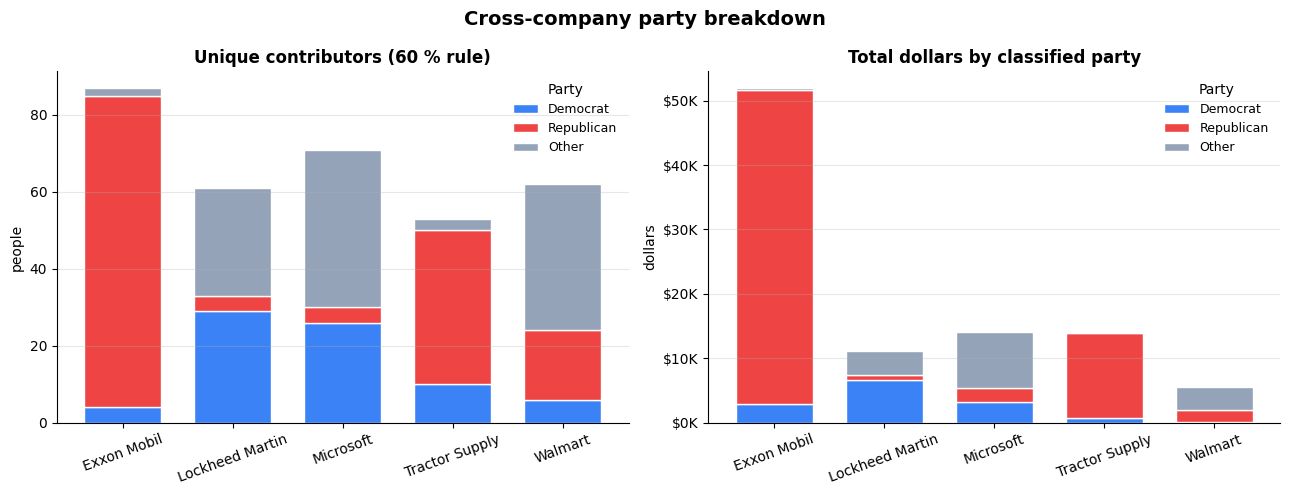

In [13]:
PARTY_COLORS = {'Democrat': '#3b82f6', 'Republican': '#ef4444', 'Other': '#94a3b8'}

def stacked_bar(df, value_col, title, ylabel, ax):
    pivot = df.pivot(index='Company', columns='mParty', values=value_col).fillna(0)
    for party in ['Democrat', 'Republican', 'Other']:
        if party not in pivot.columns:
            pivot[party] = 0
    pivot = pivot[['Democrat', 'Republican', 'Other']]
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=[PARTY_COLORS[p] for p in pivot.columns],
               edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Party', frameon=False, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Build long-form views for plotting
people_long = stats5.assign(
    Company=lambda d: d['company'].map(COMPANY_DISPLAY).fillna(d['company'])
).groupby(['Company', 'mParty']).size().reset_index(name='people')

dollars_long = stats5.assign(
    Company=lambda d: d['company'].map(COMPANY_DISPLAY).fillna(d['company'])
).groupby(['Company', 'mParty'])['contribsum'].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
stacked_bar(people_long,  'people',     'Unique contributors (60 % rule)', 'people',  ax1)
stacked_bar(dollars_long, 'contribsum', 'Total dollars by classified party', 'dollars', ax2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.suptitle('Cross-company party breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_party_stack.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
plt.show()


### Contribution time-series

Auto-picks the resampling bucket from the data span — daily for tight
windows (the default 2-page fetch is usually the most recent 200 records
per employer, often a 2-week window), weekly or monthly for wider ones.
X-axis is snapped to the data extent so a narrow window stays readable.


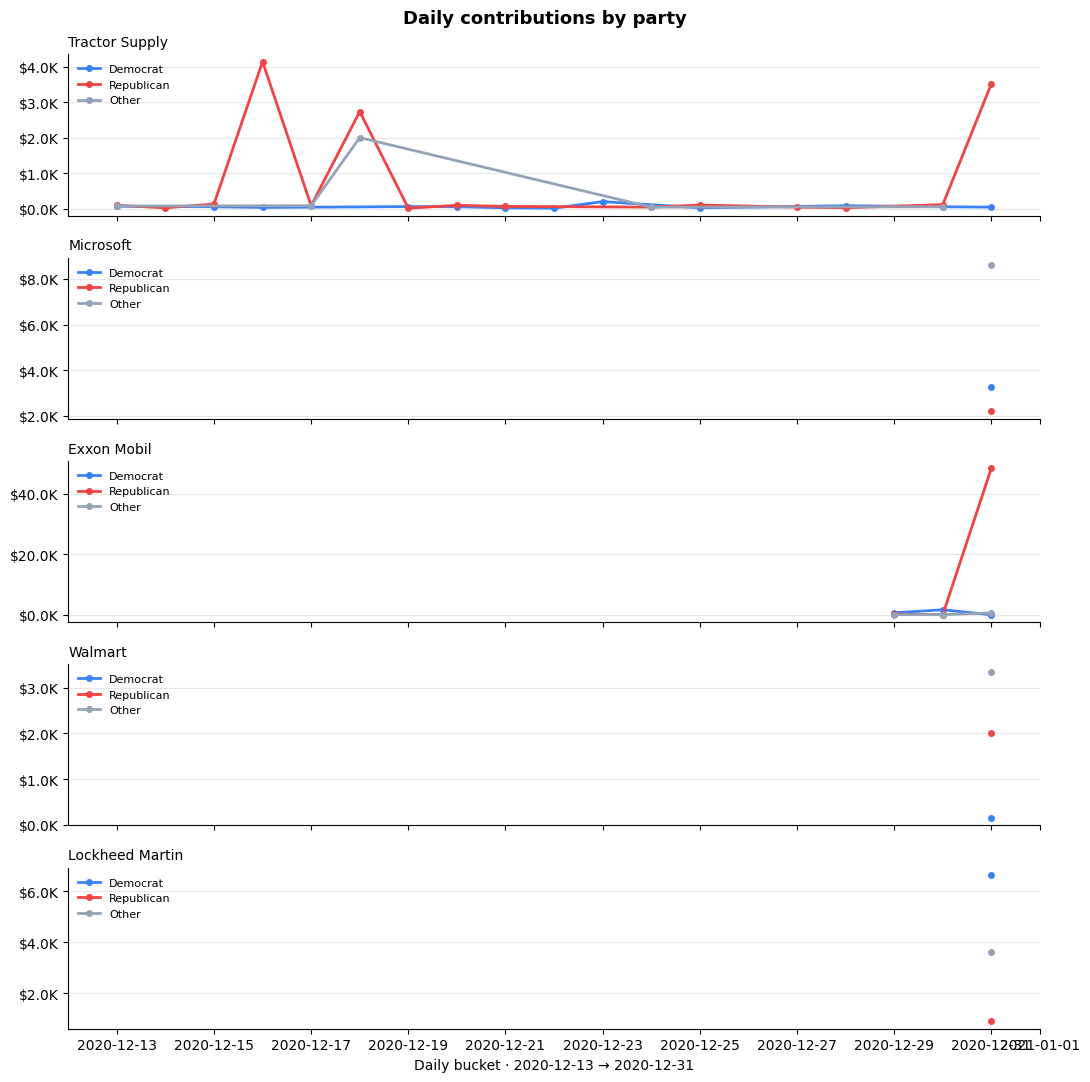

In [14]:
# Pick the resampling frequency from the actual date span — daily for short
# windows, weekly for ~3-12mo, monthly for longer. Our default 2-page sample is
# the most recent 200 records per employer, often a narrow window.
dates = saspac3['receipt_date'].dropna()
span_days = (dates.max() - dates.min()).days if not dates.empty else 0
if span_days <= 60:
    freq, freq_label = 'D', 'Daily'
elif span_days <= 365:
    freq, freq_label = 'W', 'Weekly'
else:
    freq, freq_label = 'ME', 'Monthly'

time_series = (
    saspac3.assign(bucket=saspac3['receipt_date'].dt.to_period(freq).dt.to_timestamp())
          .groupby(['company', 'bucket', 'mParty'], dropna=False)['contribsum']
          .sum().reset_index()
)

fig, axes = plt.subplots(len(ACTIVE_COMPANIES), 1,
                         figsize=(11, 2.2 * len(ACTIVE_COMPANIES)),
                         sharex=True)
if len(ACTIVE_COMPANIES) == 1:
    axes = [axes]

for ax, company in zip(axes, ACTIVE_COMPANIES):
    g = time_series[time_series['company'] == company]
    for party in ['Democrat', 'Republican', 'Other']:
        gp = g[g['mParty'] == party].sort_values('bucket')
        if gp.empty: continue
        ax.plot(gp['bucket'], gp['contribsum'],
                label=party, color=PARTY_COLORS[party],
                linewidth=2, marker='o', markersize=4)
    ax.set_title(COMPANY_DISPLAY.get(company, company), fontsize=10, loc='left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(frameon=False, fontsize=8, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Snap the x-axis to the data extent so a narrow window stays readable.
if not dates.empty:
    pad = pd.Timedelta(days=max(1, span_days // 20))
    for ax in axes:
        ax.set_xlim(dates.min() - pad, dates.max() + pad)
    axes[-1].set_xlabel(f'{freq_label} bucket · {dates.min():%Y-%m-%d} → {dates.max():%Y-%m-%d}')
else:
    axes[-1].set_xlabel('No dates available')

plt.suptitle(f'{freq_label} contributions by party',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_monthly.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
plt.show()


### Top contributing states

Combined view across all employers — which states show up most by dollars.


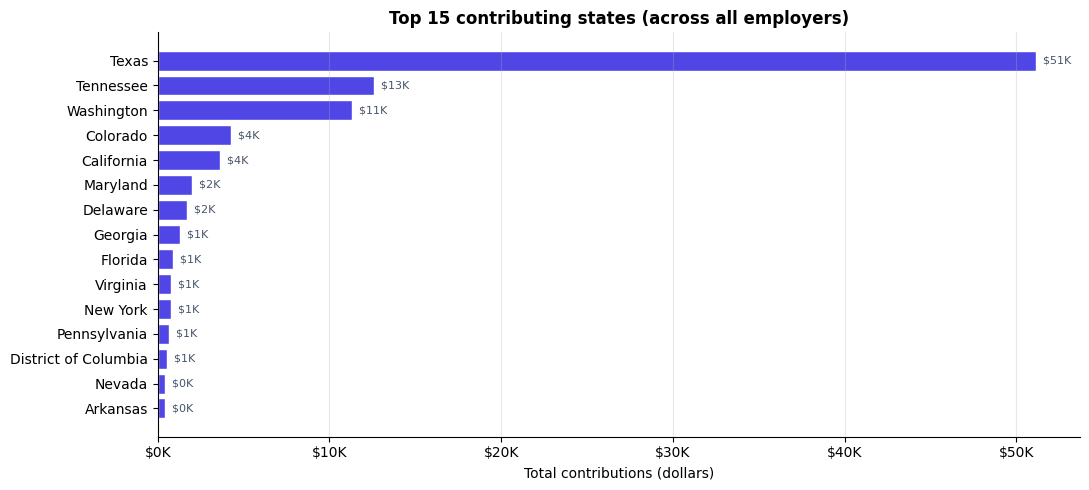

In [15]:
state_totals = (
    saspac3.groupby('statename')
          .agg(transactions=('contribsum', 'size'),
               dollars=('contribsum', 'sum'))
          .sort_values('dollars', ascending=False)
          .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(state_totals.index[::-1], state_totals['dollars'][::-1],
               color='#4f46e5', edgecolor='white')
ax.set_xlabel('Total contributions (dollars)')
ax.set_title('Top 15 contributing states (across all employers)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, value in zip(bars, state_totals['dollars'][::-1]):
    ax.text(value, bar.get_y() + bar.get_height() / 2,
            f'  ${value/1000:.0f}K', va='center', fontsize=8, color='#475569')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_top_states.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
plt.show()


#### Same data, interactive — pluggable charting

Matplotlib is the project default because it produces small static PNGs
that embed cleanly in nbconvert HTML and the GitHub Pages site. But the
notebook isn't locked to it — any library that renders inline in Jupyter
works, including:

- **[plotly](https://plotly.com/python/)** — interactive HTML, hover tooltips, zoom/pan; embeds as a self-contained `<div>` in the static export.
- **[altair](https://altair-viz.github.io/)** — declarative grammar-of-graphics on top of Vega-Lite.
- **[bokeh](https://bokeh.org/)** — server-aware interactive plots.
- **[D3](https://d3js.org/)** — full control via custom HTML/JS cells using `IPython.display.HTML`.

Swap is one import + one call. Below: the same top-states data rendered
as an interactive plotly bar — hover for exact dollar amounts, double-click
to reset zoom.


In [16]:
import plotly.express as px

fig = px.bar(
    state_totals.reset_index().sort_values('dollars'),
    x='dollars',
    y='statename',
    orientation='h',
    hover_data={'transactions': True, 'dollars': ':$,.0f'},
    color='dollars',
    color_continuous_scale='purples',
    title='Top 15 contributing states (interactive — hover to inspect)',
)
fig.update_layout(
    height=450, margin=dict(l=0, r=0, t=50, b=0),
    yaxis_title='', xaxis_title='Contributions (dollars)',
    coloraxis_showscale=False,
    plot_bgcolor='white',
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f', gridcolor='#e2e8f0')
fig.show()


### Committee-type breakdown

Where the money lands by *committee type*. `committee_type_full` (from the
embedded API field) distinguishes candidate committees from PACs
(qualified / nonqualified / hybrid), party committees, presidential, and so on.
This is one of those slices the SAS pipeline can't easily produce because
the bulk-data CSVs don't carry committee type — but the modern API does.


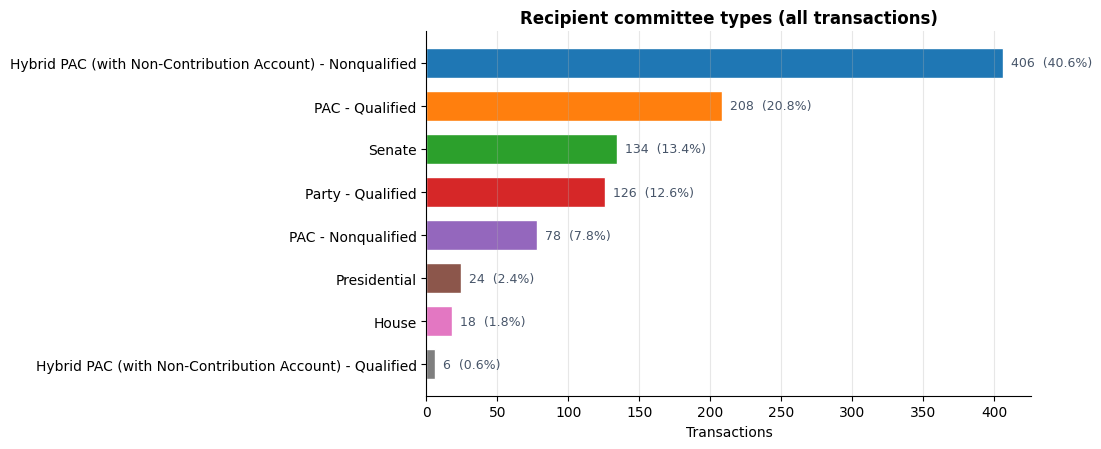

In [17]:
ctype = saspac3['committee_type_full'].fillna('Unknown').value_counts()
share = ctype / ctype.sum() * 100

fig, ax = plt.subplots(figsize=(11, max(3, 0.45 * len(ctype) + 1)))
colors = plt.cm.tab10.colors
bars = ax.barh(ctype.index[::-1], ctype.values[::-1],
               color=colors[:len(ctype)][::-1], edgecolor='white', height=0.7)
ax.set_title('Recipient committee types (all transactions)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Transactions')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, count, pct in zip(bars, ctype.values[::-1], share.values[::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f'  {count:,}  ({pct:.1f}%)', va='center', fontsize=9, color='#475569')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_committee_types.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
plt.show()


### Top recipient committees per employer

Per employer, the top 5 committees by total dollars received. The same
committee can appear under multiple employers — most corporate PACs ultimately
feed into the same handful of national fundraising vehicles (ActBlue, WinRed, etc.).


In [18]:
top_per_company = []
for company in ACTIVE_COMPANIES:
    g = saspac3[saspac3['company'] == company]
    top = (g.groupby(['committee', 'mParty'])
             .agg(transactions=('contribsum', 'size'),
                  dollars=('contribsum', 'sum'))
             .sort_values('dollars', ascending=False)
             .head(5)
             .reset_index()
             .assign(Company=COMPANY_DISPLAY.get(company, company)))
    top_per_company.append(top)

top_committees = pd.concat(top_per_company, ignore_index=True)
top_committees['dollars'] = top_committees['dollars'].map('${:,.0f}'.format)
top_committees[['Company', 'committee', 'mParty', 'transactions', 'dollars']]


,Company,committee,mParty,transactions,dollars


## 12. Recipient-side view — Schedule B (disbursements)

Up to here, every section has been about *inflow*: money flowing **from**
company employees **to** committees. But corporate PACs aren't terminal —
they receive donations, then turn around and spend them. Schedule B is the
*outflow* side of the same committee.

The plan:

1. For each employer, find the **single biggest recipient committee** in our Schedule A data (typically the company's own PAC — e.g., the *Tractor Supply Company Political Action Committee*).
2. Fetch that committee's Schedule B disbursements for the same 2019–2020 window.
3. Aggregate by recipient: which candidates / committees did each corporate PAC actually back, and with how much?

The SAS pipeline can't easily produce this view — it only ingests Schedule A
bulk data. The OpenFEC API makes Schedule B a single endpoint away.

*FEC endpoint: `/schedules/schedule_b/?committee_id=X`*


In [19]:
# Pick each company's largest recipient committee in our Schedule A window.
top_recipient_per_company = (
    saspac3.groupby(['company', 'committee_id', 'committee'], dropna=False)
          .agg(inflow_transactions=('contribsum', 'size'),
               inflow_dollars=('contribsum', 'sum'))
          .reset_index()
          .sort_values('inflow_dollars', ascending=False)
          .groupby('company', sort=False)
          .head(1)
          .reset_index(drop=True)
)
top_recipient_per_company['Company'] = top_recipient_per_company['company'].map(COMPANY_DISPLAY).fillna(top_recipient_per_company['company'])
top_recipient_per_company[['Company', 'committee', 'committee_id',
                          'inflow_transactions', 'inflow_dollars']]


,Company,committee,committee_id,inflow_transactions,inflow_dollars
0,Exxon Mobil,<NA>,C00121368,152,48177.7
1,Lockheed Martin,<NA>,C00401224,110,6160.0
2,Tractor Supply,<NA>,C00763664,54,5900.0
3,Microsoft,<NA>,C00401224,94,2973.6
4,Walmart,<NA>,C00762591,38,1330.5


In [20]:
# Fetch Schedule B for each of those committees (cached on disk after first run).
def _safe_str(v) -> str:
    return v if isinstance(v, str) else ('' if pd.isna(v) else str(v))

disbursement_frames = []
for _, row in top_recipient_per_company.iterrows():
    cid = _safe_str(row['committee_id'])
    company_disp = _safe_str(row['Company'])
    cmte_disp    = _safe_str(row['committee'])[:55]
    if not cid:
        continue
    try:
        records = client.schedule_b_pages(cid, MIN_DATE, MAX_DATE, max_pages=2)
    except Exception as e:
        print(f'• {company_disp:>18s} → {cid:<12} ! {type(e).__name__}')
        continue
    if not records:
        print(f'• {company_disp:>18s} → {cid:<12} (no disbursements)')
        continue
    df = pd.DataFrame(records)
    df['source_company']     = row['company']
    df['source_committee']   = _safe_str(row['committee'])
    df['source_committee_id'] = cid
    disbursement_frames.append(df)
    print(f'• {company_disp:>18s} → {cid:<12} {len(df):>5,} disbursements   {cmte_disp}')

if disbursement_frames:
    schedule_b = pd.concat(disbursement_frames, ignore_index=True)
    schedule_b['disbursement_date'] = pd.to_datetime(
        schedule_b['disbursement_date'], errors='coerce',
    )
else:
    schedule_b = pd.DataFrame()

print(f'\nTotal Schedule B records: {len(schedule_b):,}')
if not schedule_b.empty:
    cols = ['source_company', 'recipient_name', 'disbursement_amount',
            'disbursement_date', 'disbursement_description']
    display(schedule_b[cols].head(8))


•        Exxon Mobil → C00121368      200 disbursements   
•    Lockheed Martin → C00401224      200 disbursements   
•     Tractor Supply → C00763664        7 disbursements   
•          Microsoft → C00401224      200 disbursements   
•            Walmart → C00762591       32 disbursements   

Total Schedule B records: 639


,source_company,recipient_name,disbursement_amount,disbursement_date,disbursement_description
0,EXXON MOBIL,YVETTE4CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
1,EXXON MOBIL,VICTORIA SPARTZ FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
2,EXXON MOBIL,TONY GONZALES FOR CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
3,EXXON MOBIL,SCOTT FRANKLIN FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
4,EXXON MOBIL,PETER MEIJER FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
5,EXXON MOBIL,NEHLS FOR CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
6,EXXON MOBIL,NANCY MACE FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
7,EXXON MOBIL,MICHELLE STEEL FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATES


In [21]:
# Aggregate outflow — top destinations per source company
if schedule_b.empty:
    outflow = pd.DataFrame()
else:
    outflow = (
        schedule_b.assign(
            Company=lambda d: d['source_company'].map(COMPANY_DISPLAY).fillna(d['source_company']),
            recipient=lambda d: d['recipient_name'].fillna('— unspecified —'),
        )
        .groupby(['Company', 'recipient'])
        .agg(disbursements=('disbursement_amount', 'size'),
             dollars=('disbursement_amount', 'sum'))
        .reset_index()
        .sort_values(['Company', 'dollars'], ascending=[True, False])
    )
    top_outflow = outflow.groupby('Company', sort=False).head(5).reset_index(drop=True)
    top_outflow_display = top_outflow.copy()
    top_outflow_display['dollars'] = top_outflow_display['dollars'].map('${:,.0f}'.format)
    display(top_outflow_display)


,Company,recipient,disbursements,dollars
0,Exxon Mobil,NRSC TARGETED STATE VICTORY,2,"$120,000"
1,Exxon Mobil,BLUEGRASS COMMITTEE,2,"$10,000"
2,Exxon Mobil,CHRIS COONS FOR DELAWARE,2,"$10,000"
3,Exxon Mobil,"COTTON FOR SENATE, INC.",2,"$10,000"
4,Exxon Mobil,GEORGIANS FOR KELLY LOEFFLER,2,"$10,000"
5,Lockheed Martin,WARNOCK FOR GEORGIA,68,"$1,834"
6,Lockheed Martin,NANCY PELOSI FOR CONGRESS,12,$600
7,Lockheed Martin,NATIONAL CAMPAIGN TRAINING COMMITTEE NCTC PAC,34,$517
8,Lockheed Martin,PROGRESSIVE TAKEOVER,24,$440
9,Lockheed Martin,PROGRESSIVE ACTION POLITICAL ACTION COMMITTEE,18,$296


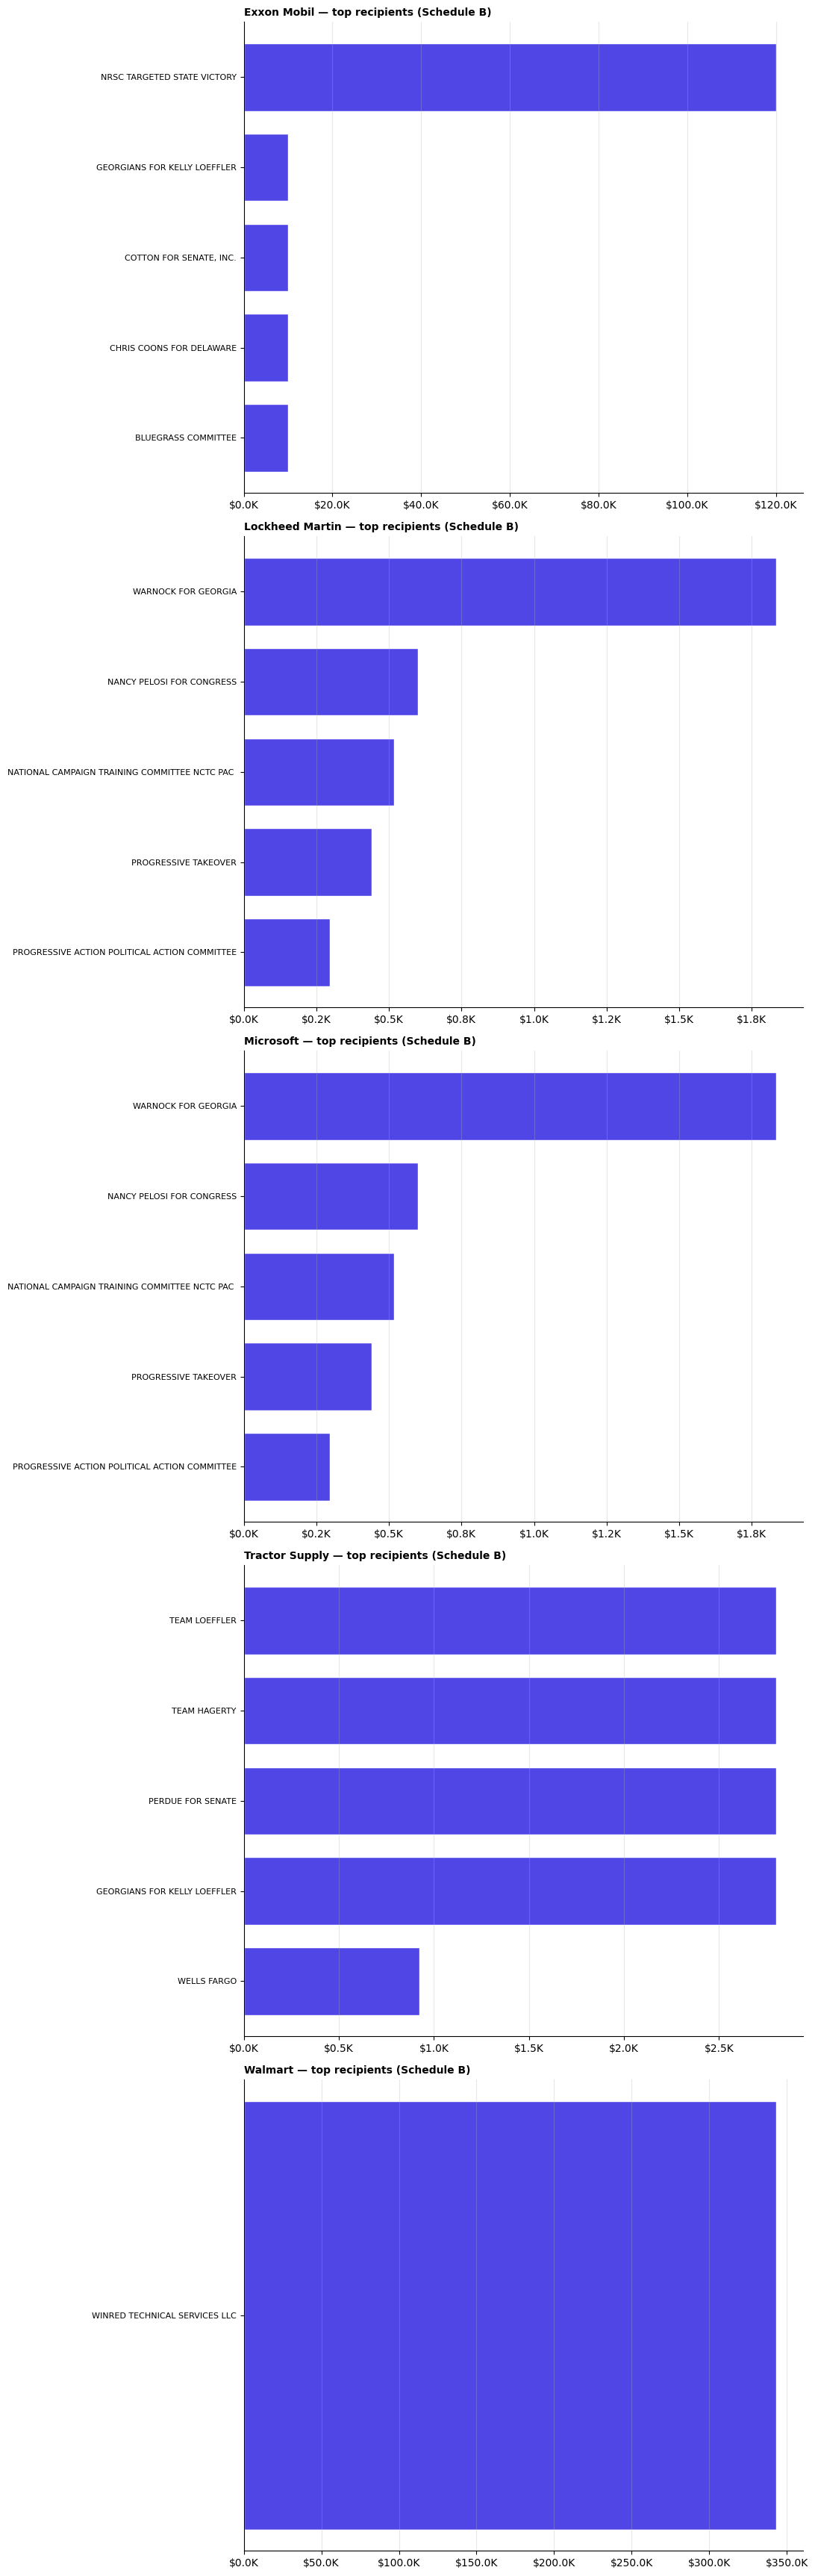

In [22]:
# Visualize: top destinations per company (horizontal bars, one row per company)
if schedule_b.empty or outflow.empty:
    print('No Schedule B data to visualize.')
else:
    companies_with_outflow = list(outflow['Company'].unique())
    fig, axes = plt.subplots(
        len(companies_with_outflow), 1,
        figsize=(11, 1.6 * sum(min(5, (outflow['Company']==c).sum()) for c in companies_with_outflow) + 1),
        squeeze=False,
    )
    axes = axes[:, 0]
    for ax, company in zip(axes, companies_with_outflow):
        g = (outflow[outflow['Company'] == company]
                    .nlargest(5, 'dollars')
                    .sort_values('dollars'))
        ax.barh(g['recipient'].str[:48], g['dollars'],
                color='#4f46e5', edgecolor='white', height=0.75)
        ax.set_title(f'{company} — top recipients (Schedule B)',
                     fontsize=10, fontweight='bold', loc='left')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    out_path = CHARTS_DIR / 'cross_company_schedule_b.png'
    plt.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.show()


### Inflow → outflow side-by-side

Inflow (Schedule A) vs outflow (Schedule B) for each company's top recipient
committee. A big `outflow / inflow` ratio means the PAC is spending more
than this employer's contributions provide — they're either hoarding from
prior cycles or pulling from many other employers we didn't fetch. Either
way, it's the kind of question Schedule A alone can't answer.

*Caveat: we only follow the **top** recipient per employer and only fetch
the first two pages of disbursements per committee — not full books.*


In [23]:
if schedule_b.empty:
    print('No Schedule B data to compare.')
else:
    outflow_by_cmte = (
        schedule_b.groupby('source_committee_id')['disbursement_amount']
                  .sum().rename('outflow_dollars')
    )
    flow = (
        top_recipient_per_company
          .rename(columns={'committee': 'Committee'})
          .merge(outflow_by_cmte.reset_index().rename(
              columns={'source_committee_id': 'committee_id'}),
              on='committee_id', how='left')
    )
    flow = flow[['Company', 'Committee', 'inflow_dollars', 'outflow_dollars']]
    flow['outflow_dollars'] = flow['outflow_dollars'].fillna(0)
    flow['ratio'] = (flow['outflow_dollars'] / flow['inflow_dollars']).round(2)
    flow_display = flow.copy()
    flow_display['inflow_dollars']  = flow_display['inflow_dollars'].map('${:,.0f}'.format)
    flow_display['outflow_dollars'] = flow_display['outflow_dollars'].map('${:,.0f}'.format)
    display(flow_display)


,Company,Committee,inflow_dollars,outflow_dollars,ratio
0,Exxon Mobil,<NA>,"$48,178","$507,490",10.53
1,Lockheed Martin,<NA>,"$6,160","$8,734",1.42
2,Tractor Supply,<NA>,"$5,900","$12,126",2.06
3,Microsoft,<NA>,"$2,974","$8,734",2.94
4,Walmart,<NA>,"$1,330","$343,078",257.86


## 13. Committee fill-in — authoritative `/committee/{id}/` lookup

Back in §4, some committees' embedded `committee.party` came back as `null`
and fell through to `'N'`. Often those are the high-traffic vehicles
(WinRed, ActBlue, individual candidate committees) where party is
structurally implied but the *embedded* response field is unset.

The single-committee endpoint sometimes returns a more authoritative party
than the embedded copy did — and even when it doesn't, the `committee_type`
and `designation_full` it returns are enough to classify by intent
(e.g., a Senate-candidate committee with no `party` field is still
obviously partisan-coded).

Why this matters: it's a working answer to the design-doc claim that for
future ports we no longer strictly need the bundled `AllPacs.xslx.csv`.

*FEC endpoint: `/committee/{id}/`*


In [24]:
# Top committees that fell to code='N'
fell_through = (
    saspac3[saspac3['code'] == 'N']
          .groupby(['committee_id', 'committee'], dropna=False)
          .agg(transactions=('contribsum', 'size'),
               dollars=('contribsum', 'sum'))
          .reset_index()
          .sort_values('dollars', ascending=False)
          .head(8)
)
print(f'{len(fell_through)} committee(s) fell through to code=N (showing top 8 by dollars)')

rows = []
for _, r in fell_through.iterrows():
    cid = r['committee_id'] if isinstance(r['committee_id'], str) else ''
    if not cid:
        continue
    cmte_label = r['committee'] if isinstance(r['committee'], str) else ''
    try:
        data = client.committee(cid)
        hits = data.get('results') or []
        meta = hits[0] if hits else {}
    except Exception as e:
        print(f'  ! {cid}: {type(e).__name__}: {e}')
        meta = {}
    rows.append({
        'committee_id': cid,
        'committee': cmte_label[:55],
        'tx_count':  int(r['transactions']),
        'dollars':   r['dollars'],
        'auth_party': meta.get('party') or '—',
        'auth_type':  meta.get('committee_type_full') or '—',
        'auth_designation': meta.get('designation_full') or '—',
    })

committee_fillin = pd.DataFrame(
    rows,
    columns=['committee_id', 'committee', 'tx_count', 'dollars',
             'auth_party', 'auth_type', 'auth_designation'],
)

if committee_fillin.empty:
    print('No N-coded committees to look up.')
else:
    display_view = committee_fillin.copy()
    display_view['dollars'] = display_view['dollars'].map('${:,.0f}'.format)
    display(display_view)
    filled = (committee_fillin['auth_party'] != '—').sum()
    print(f'\n→ /committee/ resolved a party for {filled} / {len(committee_fillin)} committees that fell to N.')


0 committee(s) fell through to code=N (showing top 8 by dollars)
No N-coded committees to look up.


## 14. Candidate enrichment — who actually received the money?

Schedule B's `recipient_name` is a *committee* name ("GEORGIANS FOR KELLY
LOEFFLER") — useful, but it doesn't carry the candidate's party in a
structured way. The `candidate_id` does, and
[`/candidate/{id}/`](https://api.open.fec.gov/) returns each candidate's
authoritative party, office (House / Senate / Presidential), and state.

We look up the **top 20 candidates by Schedule B dollars**, then join the
party back onto the disbursement table. That lets us answer:

> **Per corporate PAC, what share of the outflow ultimately landed with
> Democratic candidates vs. Republican candidates?**

Neither Schedule B alone nor the SAS pipeline can answer that. Both stop
at the committee name; the candidate party only comes from this endpoint.

*FEC endpoint: `/candidate/{id}/`*


In [25]:
# Top recipient candidates across all Schedule B disbursements
if schedule_b.empty or 'candidate_id' not in schedule_b.columns:
    candidate_enrich = pd.DataFrame()
    schedule_b_party = pd.DataFrame()
else:
    top_candidates = (
        schedule_b[schedule_b['candidate_id'].notna()]
                  .groupby('candidate_id')['disbursement_amount']
                  .agg(['count', 'sum'])
                  .sort_values('sum', ascending=False)
                  .head(20)
                  .reset_index()
    )
    print(f'Looking up {len(top_candidates)} candidate(s) via /candidate/…')
    enriched_rows = []
    for _, r in top_candidates.iterrows():
        cand_id = r['candidate_id']
        if not isinstance(cand_id, str) or not cand_id:
            continue
        try:
            data = client.candidate(cand_id)
            hits = data.get('results') or []
            meta = hits[0] if hits else {}
        except Exception as e:
            print(f'  ! {cand_id}: {type(e).__name__}: {e}')
            meta = {}
        enriched_rows.append({
            'candidate_id':   cand_id,
            'name':           meta.get('name') or '—',
            'party':          meta.get('party_full') or meta.get('party') or '—',
            'party_code':     meta.get('party') or '',
            'office':         meta.get('office_full') or '—',
            'state':          meta.get('state') or '—',
            'disbursements':  int(r['count']),
            'dollars':        float(r['sum']),
        })
    candidate_enrich = pd.DataFrame(enriched_rows)

if candidate_enrich.empty:
    print('No candidate_id values in this Schedule B sample.')
else:
    view = candidate_enrich.copy()
    view['dollars'] = view['dollars'].map('${:,.0f}'.format)
    display(view)


Looking up 20 candidate(s) via /candidate/…


,candidate_id,name,party,party_code,office,state,disbursements,dollars
0,S4GA11285,"PERDUE, DAVID",REPUBLICAN PARTY,REP,Senate,GA,3,"$12,800"
1,S0TN00169,"HAGERTY, BILL",REPUBLICAN PARTY,REP,Senate,TN,3,"$12,800"
2,S0GA00526,"LOEFFLER, KELLY",REPUBLICAN PARTY,REP,Senate,GA,3,"$12,800"
3,S4AR00103,"COTTON, THOMAS",REPUBLICAN PARTY,REP,Senate,AR,2,"$10,000"
4,S0DE00092,"COONS, CHRISTOPHER A.",DEMOCRATIC PARTY,DEM,Senate,DE,2,"$10,000"
5,H6NJ05171,"GOTTHEIMER, JOSH",DEMOCRATIC PARTY,DEM,House,NJ,4,"$8,000"
6,H8LA02054,"RICHMOND, CEDRIC L",DEMOCRATIC PARTY,DEM,House,LA,4,"$8,000"
7,H8OR05107,"SCHRADER, KURT",DEMOCRATIC PARTY,DEM,House,OR,4,"$7,000"
8,H2TX33073,"VEASEY, MARC ALLISON",DEMOCRATIC PARTY,DEM,House,TX,4,"$7,000"
9,H0FL15104,"FRANKLIN, SCOTT MR.",REPUBLICAN PARTY,REP,House,FL,4,"$6,000"


### Outflow by recipient candidate party

The full payoff: each PAC's outflow split by the party of the candidates
the money ultimately reached. Useful for spotting employees whose PAC
tilts opposite their own contributor lean, or PACs that hedge heavily
across both sides.


        Company  recipient_party  disbursement_amount
    Exxon Mobil         Democrat             75000.00
    Exxon Mobil Other / unmapped            371490.00
    Exxon Mobil       Republican             61000.00
Lockheed Martin         Democrat                 4.00
Lockheed Martin Other / unmapped              4362.98
      Microsoft         Democrat                 4.00
      Microsoft Other / unmapped              4362.98
 Tractor Supply Other / unmapped              3725.98
 Tractor Supply       Republican              8400.00
        Walmart Other / unmapped            343077.51



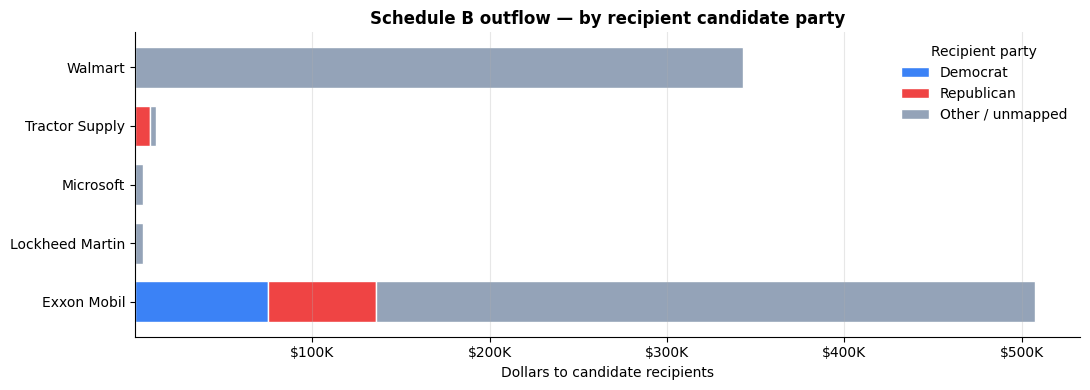

In [26]:
if candidate_enrich.empty:
    print('No candidate enrichment available — skipping chart.')
else:
    enriched_sb = schedule_b.merge(
        candidate_enrich[['candidate_id', 'party_code']],
        on='candidate_id', how='left',
    )
    def _major(code):
        if code == 'DEM': return 'Democrat'
        if code == 'REP': return 'Republican'
        return 'Other / unmapped'
    enriched_sb['recipient_party'] = enriched_sb['party_code'].map(_major)

    outflow_by_party = (
        enriched_sb.assign(
            Company=lambda d: d['source_company'].map(COMPANY_DISPLAY).fillna(d['source_company']),
        )
        .groupby(['Company', 'recipient_party'])['disbursement_amount']
        .sum().reset_index()
    )
    print(outflow_by_party.to_string(index=False))
    print()

    pivot = (
        outflow_by_party.pivot(index='Company', columns='recipient_party',
                              values='disbursement_amount')
        .fillna(0)
    )
    for col in ['Democrat', 'Republican', 'Other / unmapped']:
        if col not in pivot.columns:
            pivot[col] = 0.0
    pivot = pivot[['Democrat', 'Republican', 'Other / unmapped']]

    fig, ax = plt.subplots(figsize=(11, 4))
    pivot.plot(kind='barh', stacked=True, ax=ax,
               color=['#3b82f6', '#ef4444', '#94a3b8'],
               edgecolor='white', width=0.7)
    ax.set_title('Schedule B outflow — by recipient candidate party',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Dollars to candidate recipients')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend(title='Recipient party', frameon=False)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    out_path = CHARTS_DIR / 'cross_company_outflow_by_party.png'
    plt.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.show()


## 15. Save SAS-parity outputs

Written to `output/tables/`; the existing build-site picks them up under
the [Data tab](../../data/) automatically.


In [27]:
company_contributors.to_csv(TABLES_DIR / 'company_contributors.csv', index=False)
company_contributions.to_csv(TABLES_DIR / 'company_contributions.csv', index=False)
stats5.head(200).to_csv(TABLES_DIR / 'stats5all_sample.csv', index=False)
saspac3.head(500).to_csv(TABLES_DIR / 'saspac3all_sample.csv', index=False)

# Recipient-side outputs (Schedule B disbursements)
if not schedule_b.empty:
    schedule_b.head(500).to_csv(TABLES_DIR / 'schedule_b_sample.csv', index=False)
    top_outflow.to_csv(TABLES_DIR / 'top_outflow_per_company.csv', index=False)

# Committee fill-in lookup (where /committee/ enriched the data)
if 'committee_fillin' in dir() and not committee_fillin.empty:
    committee_fillin.to_csv(TABLES_DIR / 'committee_fillin.csv', index=False)

# Candidate enrichment (/candidate/{id}/ lookups for Schedule B recipients)
if 'candidate_enrich' in dir() and not candidate_enrich.empty:
    candidate_enrich.to_csv(TABLES_DIR / 'candidate_enrichment.csv', index=False)

# Bundle the two contributor/contribution summaries in one Excel workbook
# (parity with SAS's company_contributors.xlsx + company_contributions.xlsx)
with pd.ExcelWriter(TABLES_DIR / 'company_summaries.xlsx', engine='openpyxl') as w:
    company_contributors.to_excel(w, sheet_name='contributors', index=False)
    company_contributions.to_excel(w, sheet_name='contributions', index=False)

# Headline metrics for the landing page — single source of truth.
summary = {
    'companies'           : ACTIVE_COMPANIES,
    'company_display'     : [COMPANY_DISPLAY.get(c, c) for c in ACTIVE_COMPANIES],
    'total_transactions'  : int(len(saspac3)),
    'unique_contributors' : int(len(stats5)),
    'inflow_dollars'      : float(saspac3['contribsum'].sum()),
    'outflow_dollars'     : float(schedule_b['disbursement_amount'].sum()) if not schedule_b.empty else 0.0,
    'outflow_records'     : int(len(schedule_b)),
    'outflow_committees'  : int(schedule_b['source_committee_id'].nunique()) if not schedule_b.empty else 0,
    'states'              : int(saspac3['state'].nunique()),
    'candidates_enriched' : int(len(candidate_enrich)) if 'candidate_enrich' in dir() else 0,
    'committee_lookups'   : int(len(committee_fillin)) if 'committee_fillin' in dir() else 0,
    'min_date'            : MIN_DATE,
    'max_date'            : MAX_DATE,
}
(TABLES_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))

for p in sorted(TABLES_DIR.iterdir()):
    print(f'  {p.relative_to(ROOT)}   {p.stat().st_size // 1024} KB')


  output/tables/candidate_enrichment.csv   1 KB
  output/tables/company_contributions.csv   0 KB
  output/tables/company_contributors.csv   0 KB
  output/tables/company_summaries.xlsx   7 KB
  output/tables/saspac3all_sample.csv   122 KB
  output/tables/schedule_b_sample.csv   1793 KB
  output/tables/stats5all_sample.csv   52 KB
  output/tables/summary.json   0 KB
  output/tables/top_outflow_per_company.csv   1 KB


## 16. Summary


In [28]:
total_txns    = len(saspac3)
total_people  = len(stats5)
total_dollars = saspac3['contribsum'].sum()
n_companies   = len(ACTIVE_COMPANIES)
share_D = (stats5['mParty'] == 'Democrat').mean() * 100
share_R = (stats5['mParty'] == 'Republican').mean() * 100
share_O = (stats5['mParty'] == 'Other').mean() * 100

print('=' * 64)
print(f'  Cross-company FEC analysis — {MIN_DATE} → {MAX_DATE}')
print('=' * 64)
print(f'  Companies analyzed   : {n_companies}')
print(f'  Total transactions   : {total_txns:>10,}')
print(f'  Unique contributors  : {total_people:>10,}')
print(f'  Total dollars        : ${total_dollars:>12,.2f}')
print(f'  Avg txns / person    : {total_txns / max(total_people, 1):>10.2f}')
print()
print(f'  Contributor classification (60 % rule):')
print(f'    Democrat   : {share_D:>5.1f}%')
print(f'    Republican : {share_R:>5.1f}%')
print(f'    Other / N  : {share_O:>5.1f}%')
print()
if not schedule_b.empty:
    sb_total = schedule_b['disbursement_amount'].sum()
    sb_rows  = len(schedule_b)
    sb_cmtes = schedule_b['source_committee_id'].nunique()
    print(f'  Recipient-side view (Schedule B):')
    print(f'    Committees followed     : {sb_cmtes}')
    print(f'    Disbursement records    : {sb_rows:>10,}')
    print(f'    Total outflow dollars   : ${sb_total:>12,.2f}')
if not committee_fillin.empty:
    print(f'  Committee fill-in :       {len(committee_fillin)} committees looked up via /committee/')
if not candidate_enrich.empty:
    print(f'  Candidates enriched:      {len(candidate_enrich)} candidates looked up via /candidate/')
print('=' * 64)


  Cross-company FEC analysis — 2019-01-01 → 2020-12-31
  Companies analyzed   : 5
  Total transactions   :      1,000
  Unique contributors  :        334
  Total dollars        : $   96,733.02
  Avg txns / person    :       2.99

  Contributor classification (60 % rule):
    Democrat   :  22.5%
    Republican :  44.0%
    Other / N  :  33.5%

  Recipient-side view (Schedule B):
    Committees followed     : 4
    Disbursement records    :        639
    Total outflow dollars   : $  871,427.45
  Candidates enriched:      20 candidates looked up via /candidate/
